# Visualization of Feature Distribution by region, cluster, etc

## Plot Feature Distribution - All cells

In [34]:
import pandas as pd

df = pd.read_parquet("./results/new2/microglia_region_split.parquet")

feature_cols = [
    "slide",
    "brain_slice",
    "label",
    "soma_area",
    "cell_area",
    "solidity",
    "sholl_auc",
    "sholl_depth",
    "sholl_max",
    "sholl_10",
    "sholl_20",
    "sholl_30",
    "sholl_40",
    "sholl_50",
    "sholl_60",
    "sholl_70",
    "sholl_80",
    "sholl_90",
    "sholl_100",
    "sholl_110",
    "sholl_120",
    "sholl_130",
    "sholl_140",
    "sholl_150",
    "sholl_160",
    "sholl_170",
    "sholl_180",
    "sholl_190",
    "sholl_200",
    "sholl_decay",
]
print(len(df))
df = df[df["region"] == "CTX"]
print(len(df))
df = df[feature_cols]
grouped_df = df.groupby(["slide", "brain_slice", "label"]).mean()

grouped_df = grouped_df.reset_index()

100417
52584


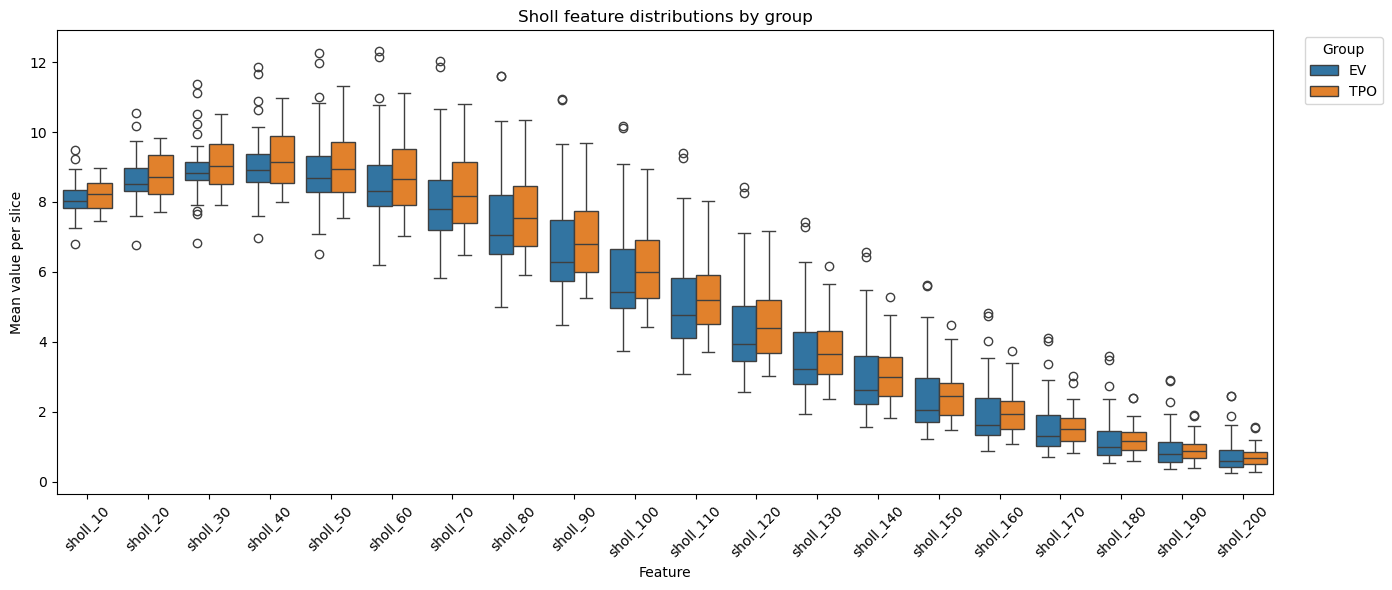

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

feature_cols = [
    "slide",
    "brain_slice",
    "label",
    "terminal_pts",
    "main_branches",
    "soma_area",
    "cell_area",
    "density",
    "sholl_auc",
    "soma_circularity",
    "sholl_depth",
    "sholl_max",
    "branching_nodes",
    "sholl_10",
    "sholl_20",
    "sholl_30",
    "sholl_40",
    "sholl_50",
    "sholl_60",
    "sholl_70",
    "sholl_80",
    "sholl_90",
    "sholl_100",
    "sholl_110",
    "sholl_120",
    "sholl_130",
    "sholl_140",
    "sholl_150",
    "sholl_160",
    "sholl_170",
    "sholl_180",
    "sholl_190",
    "sholl_200",
    "tortuosity",
    "sholl_decay",
    "amt_branches",
    "mean_segment_length",
    "max_segment_length",
    "mean_thickness",
    "max_thickness",
]


sholl_features = [
    c
    for c in grouped_df.columns
    if c.startswith("sholl_")
    and (
        c not in "sholl_max"
        and c not in "sholl_depth"
        and c not in "sholl_auc"
        and c not in "sholl_decay"
    )
]
grouped_df["group"] = grouped_df["label"].map({0: "EV", 1: "TPO"})


def make_boxplot(df, features, title, ylabel, figsize=(12, 6)):
    long_df = df.melt(
        id_vars=["slide", "brain_slice", "label", "group"],
        value_vars=features,
        var_name="feature",
        value_name="value",
    )

    plt.figure(figsize=(max(figsize[0], len(features) * 0.7), figsize[1]))

    ax = sns.boxplot(
        data=long_df,
        x="feature",
        y="value",
        hue="group",
        showfliers=True,
        hue_order=["EV", "TPO"],
    )


    ax.set_xlabel("Feature")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)

    handles, labels = ax.get_legend_handles_labels()
    unique = {}
    for h, l in zip(handles, labels):
        if l not in unique:
            unique[l] = h
    ax.legend(
        unique.values(),
        unique.keys(),
        title="Group",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    plt.tight_layout()
    plt.show()



make_boxplot(
    grouped_df,
    sholl_features,
    title="Sholl feature distributions by group",
    ylabel="Mean value per slice",
)

## Density Boxplots by region and slice

/tmp/ipykernel_61962/1737539252.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())


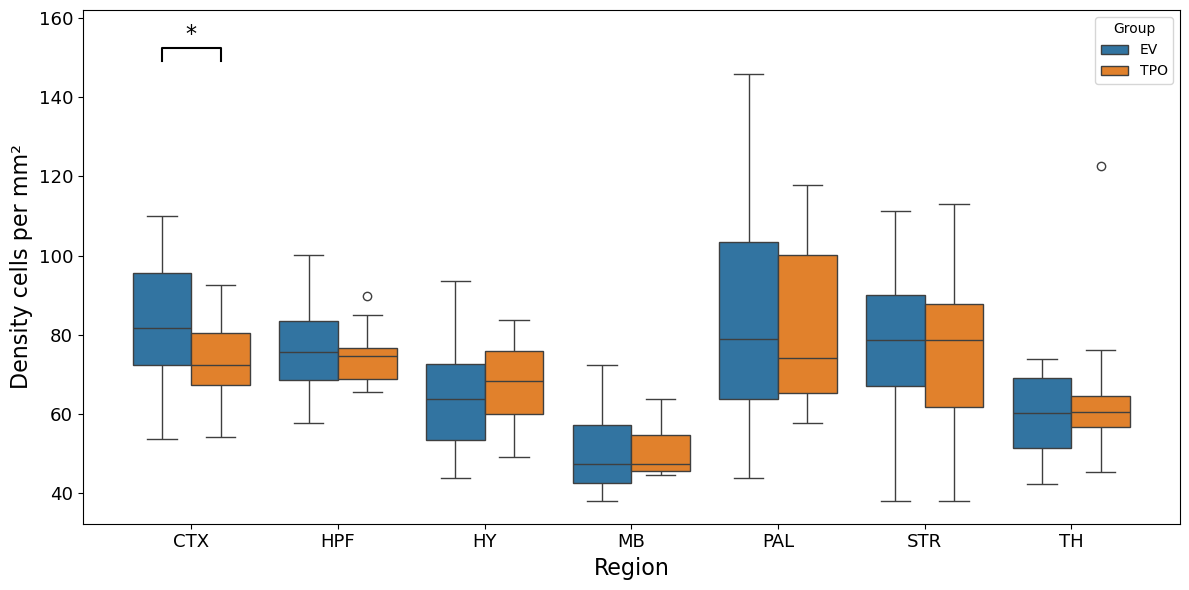

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_parquet("./results/new2/regional_density_cleaned.parquet")

feature_col = "density_cells_per_mm2"

grouped_df = df[["slide", "region_title", feature_col]].copy()

grouped_df["group"] = grouped_df["slide"].apply(
    lambda x: "EV" if "EV" in str(x) else ("TPO" if "TPO" in str(x) else None)
)

grouped_df = grouped_df[grouped_df["group"].notna()]

region_order = sorted(grouped_df["region_title"].dropna().unique())

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=grouped_df,
    x="region_title",
    y=feature_col,
    hue="group",
    order=region_order,
    hue_order=["EV", "TPO"],
    ax=ax,
)

if "CTX" in region_order:
    ctx_x = region_order.index("CTX")

    x1, x2 = ctx_x - 0.2, ctx_x + 0.2

    ctx_data = grouped_df[grouped_df["region_title"] == "CTX"][feature_col]
    y = grouped_df[feature_col].max()
    h = (grouped_df[feature_col].max() - grouped_df[feature_col].min()) * 0.03
    text = "*"

    ax.plot([x1, x1, x2, x2], [y + h, y + 2 * h, y + 2 * h, y + h], lw=1.5, c="k")
    ax.text(
        (x1 + x2) * 0.5,
        y + 2.2 * h,
        text,
        ha="center",
        va="bottom",
        color="k",
        fontsize=16,
    )
    ax.set_ylim(top=y + 5 * h)

ax.set_xticklabels(ax.get_xticklabels())
ax.set_xlabel("Region", fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=13)
ax.set_ylabel("Density cells per mm²", fontsize=16)
ax.legend(title="Group")
plt.tight_layout()
plt.savefig("regional_density_boxplot.pdf", dpi=300)
plt.show()

/tmp/ipykernel_15304/1291447589.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


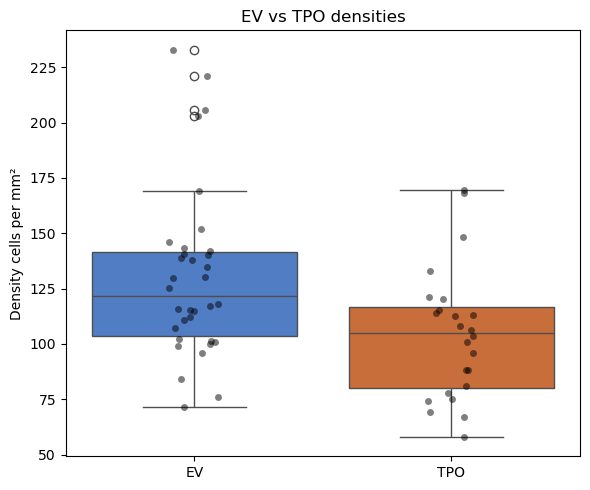

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ev_densities = [
    107,
    99,
    84,
    76,
    71.5,
    100,
    101,
    140,
    221,
    115,
    117,
    118,
    138,
    142,
    169.1,
    232.9,
    115.1,
    143.3,
    130.3,
    146,
    129.6,
    140.7,
    205.5,
    112.2,
    95.7,
    110.7,
    152,
    138.9,
    134.9,
    203,
    102.3,
    125.3,
    101.3,
    115.7,
]
tpo_densities = [
    112.9,
    148.3,
    67,
    113.9,
    88,
    168,
    120.3,
    88,
    106.3,
    112.4,
    169.63,
    115.4,
    69.3,
    121.3,
    103.7,
    133,
    108,
    58,
    101,
    74,
    96,
    78,
    75,
    81,
]


plot_df = pd.DataFrame(
    {
        "density": ev_densities + tpo_densities,
        "group": ["EV"] * len(ev_densities) + ["TPO"] * len(tpo_densities),
    }
)

palette = {"EV": "#3E79D8", "TPO": "#E06823"}

plt.figure(figsize=(6, 5))
sns.boxplot(data=plot_df, x="group", y="density", palette=palette)
sns.stripplot(
    data=plot_df, x="group", y="density", color="black", alpha=0.5, jitter=True
)

plt.ylabel("Density cells per mm²")
plt.xlabel("")
plt.title("EV vs TPO densities")
plt.tight_layout()
plt.show()

## Density Heatmap

In [1]:
import pandas as pd
import pyvips

file = "/mnt/d/microglia_data/TPO_60.tiff"
vips_img = pyvips.Image.new_from_file(str(file), access="random")
cells = pd.read_parquet("./results/new2/microglia_features_slice.parquet")

cells = cells[cells["slide"] == "TPO_60"]
cells = cells[cells["brain_slice"] == 5]

cells["gx"] = cells["cx"] + cells["x1"]
cells["gy"] = cells["cy"] + cells["y1"]


file2 = "/mnt/d/microglia_data/TPO_61_EV.tiff"
vips_img2 = pyvips.Image.new_from_file(str(file2), access="random")
cells2 = pd.read_parquet("./results/new2/microglia_features_slice.parquet")

cells2 = cells2[cells2["slide"] == "TPO_61_EV"]
cells2 = cells2[cells2["brain_slice"] == 4]

cells2["gx"] = cells2["cx"] + cells2["x1"]
cells2["gy"] = cells2["cy"] + cells2["y1"]

cells2

,slide,label,x1,y1,x2,y2,cx,cy,soma_area,soma_radius,...,sholl_190,sholl_200,sholl_210,sholl_220,sholl_230,sholl_240,sholl_250,brain_slice,gx,gy
16804,TPO_61_EV,0,104192,31232,104588,31693,245,152,1225,20.207944,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,104437,31384
16805,TPO_61_EV,0,104845,13625,105126,13824,146,55,3250,39.063214,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,104991,13680
16806,TPO_61_EV,0,104940,20992,105216,21504,140,165,1215,20.825235,...,6.0,5.0,3.0,2.0,3.0,3.0,0.0,4,105080,21157
16807,TPO_61_EV,0,105042,21504,105216,21907,103,191,2931,34.730785,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,105145,21695
16808,TPO_61_EV,0,104873,29696,105216,29986,174,155,2167,27.227258,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,105047,29851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19326,TPO_61_EV,0,128351,18482,128504,18575,128,30,1995,30.979310,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,128479,18512
19327,TPO_61_EV,0,128256,19200,128681,19700,333,252,1636,23.428908,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,128589,19452
19328,TPO_61_EV,0,128635,20046,128724,20126,41,41,1313,22.481625,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,128676,20087
19329,TPO_61_EV,0,128512,20736,128848,21248,140,331,2421,61.793282,...,4.0,5.0,3.0,1.0,0.0,0.0,0.0,4,128652,21067


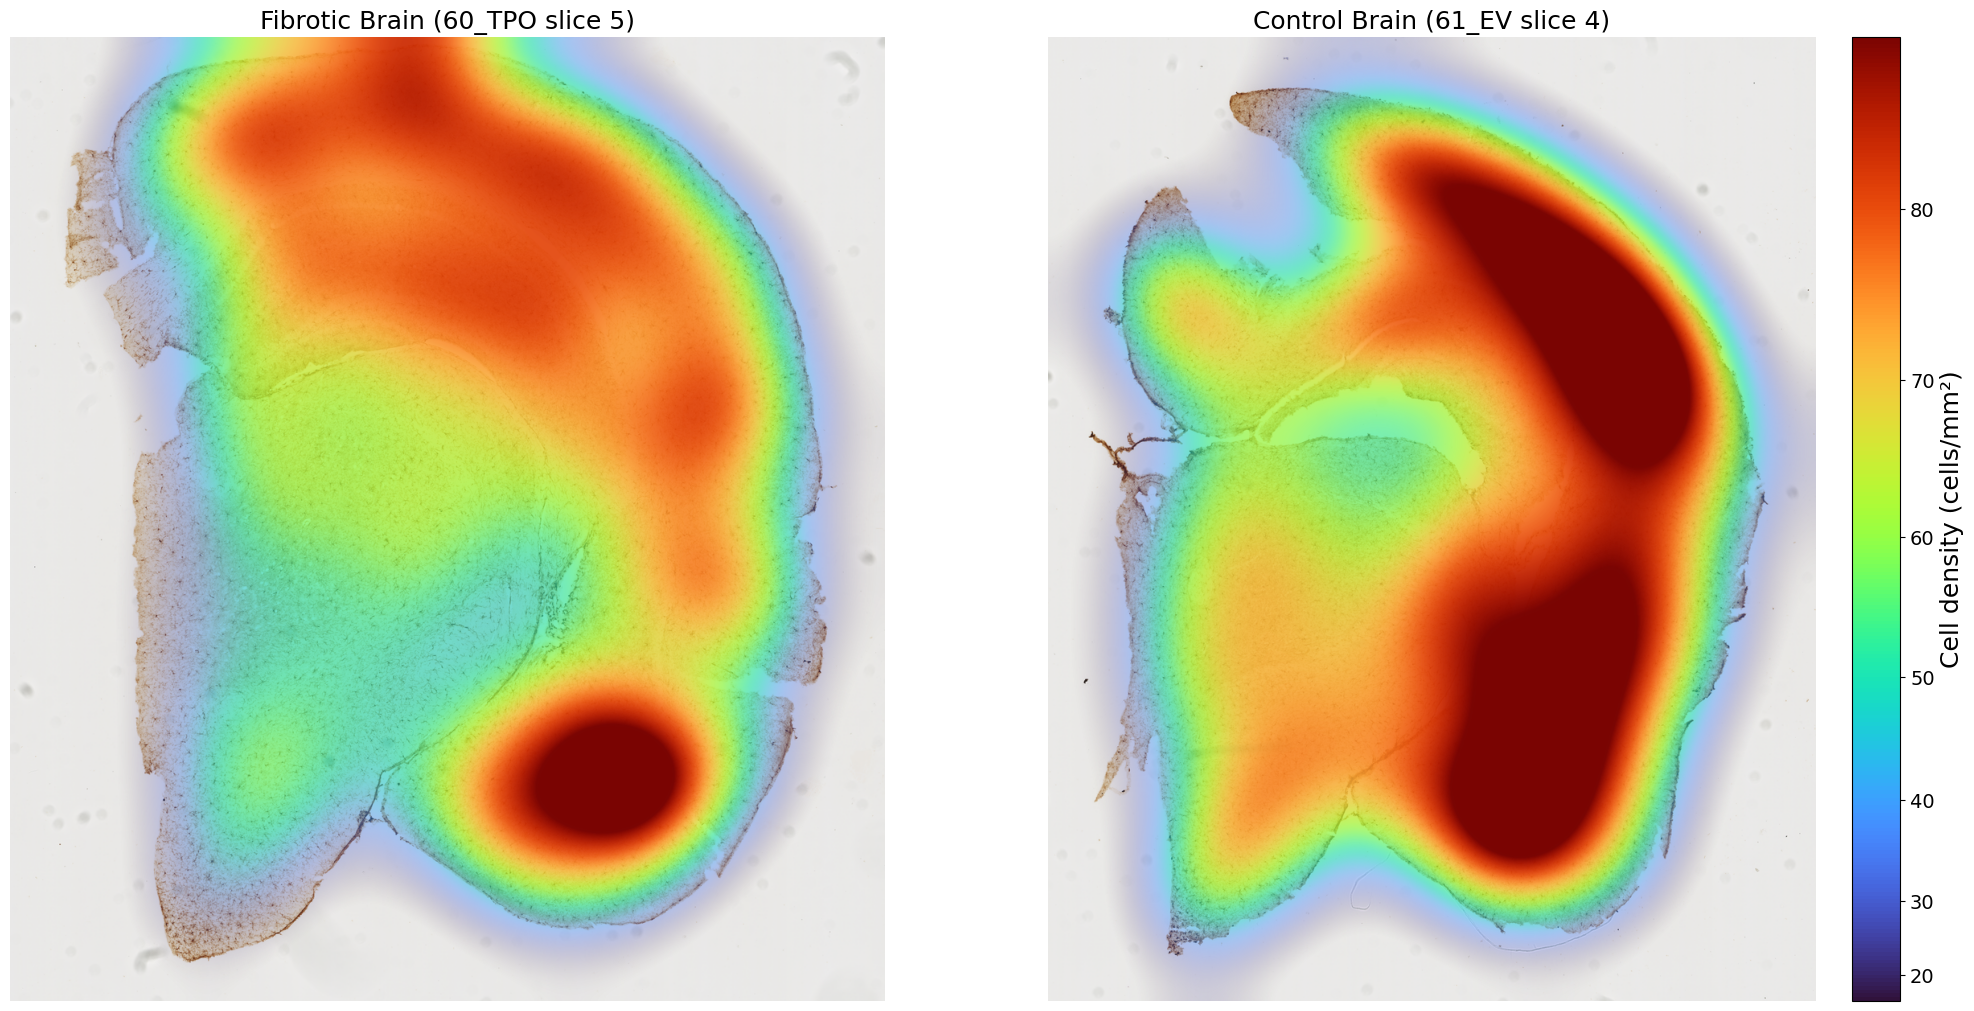

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, FuncFormatter
from scipy.ndimage import gaussian_filter


pad = 2000
max_side = 1200
um_per_pixel = 0.2276
sigma_frac = 0.06
fade_power = 1.5


def vips_to_numpy(img):
    dtype_map = {
        "uchar": np.uint8,
        "char": np.int8,
        "ushort": np.uint16,
        "short": np.int16,
        "uint": np.uint32,
        "int": np.int32,
        "float": np.float32,
        "double": np.float64,
    }

    arr = np.frombuffer(img.write_to_memory(), dtype=dtype_map[img.format])

    arr = arr.reshape(img.height, img.width, img.bands)

    if arr.ndim == 3 and arr.shape[2] == 1:
        arr = arr[:, :, 0]
    elif arr.ndim == 3 and arr.shape[2] >= 3:
        arr = arr[:, :, :3]

    return arr


def compute_density(cells, vips_img):

    x0 = max(int(cells["gx"].min()) - pad, 0)
    y0 = max(int(cells["gy"].min()) - pad, 0)
    x1 = min(int(cells["gx"].max()) + pad, vips_img.width)
    y1 = min(int(cells["gy"].max()) + pad, vips_img.height)

    w = x1 - x0
    h = y1 - y0

    roi_cells = cells[
        (cells["gx"] >= x0)
        & (cells["gx"] < x1)
        & (cells["gy"] >= y0)
        & (cells["gy"] < y1)
    ]

    scale = min(max_side / max(w, h), 1.0)

    disp_w = max(1, int(round(w * scale)))
    disp_h = max(1, int(round(h * scale)))

    ix = ((roi_cells["gx"].to_numpy() - x0) * disp_w / w).astype(np.int64)
    iy = ((roi_cells["gy"].to_numpy() - y0) * disp_h / h).astype(np.int64)

    ix = np.clip(ix, 0, disp_w - 1)
    iy = np.clip(iy, 0, disp_h - 1)

    counts = (
        np.bincount(iy * disp_w + ix, minlength=disp_w * disp_h)
        .reshape(disp_h, disp_w)
        .astype(np.float32)
    )

    sigma = max(disp_w, disp_h) * sigma_frac
    counts_smooth = gaussian_filter(counts, sigma=sigma)

    effective_um_per_bin = um_per_pixel / scale
    bin_area_mm2 = (effective_um_per_bin / 1000.0) ** 2

    density_mm2 = counts_smooth / bin_area_mm2

    roi = vips_img.crop(x0, y0, w, h)

    if scale < 1.0:
        roi = roi.resize(scale)

    roi_np = vips_to_numpy(roi)

    return roi_np, density_mm2


roi1, density1 = compute_density(cells, vips_img)
roi2, density2 = compute_density(cells2, vips_img2)

all_positive = np.concatenate(
    [density1[density1 > 0].ravel(), density2[density2 > 0].ravel()]
)

vmin = np.percentile(all_positive, 20)
vmax = np.percentile(all_positive, 95)
cmap = plt.cm.turbo


norm = LogNorm(vmin=vmin, vmax=vmax)
from matplotlib.colors import PowerNorm

norm = PowerNorm(gamma=1.5, vmin=vmin, vmax=vmax)


def make_alpha(density):

    alpha = np.zeros_like(density)

    mask = density > 0

    alpha[mask] = (
        np.clip(
            (np.log10(density[mask]) - np.log10(vmin))
            / (np.log10(vmax) - np.log10(vmin)),
            0,
            1,
        )
        ** fade_power
    )

    return alpha


alpha1 = make_alpha(density1)
alpha2 = make_alpha(density2)

fig, axes = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)

titles = ["Fibrotic Brain (60_TPO slice 5)", "Control Brain (61_EV slice 4)"]

for ax, roi, density, alpha, title in zip(
    axes, [roi1, roi2], [density1, density2], [alpha1, alpha2], titles
):

    if roi.ndim == 2:
        ax.imshow(roi, cmap="gray", origin="upper")
    else:
        ax.imshow(roi, origin="upper")

    ax.imshow(
        density,
        cmap=cmap,
        norm=norm,
        alpha=alpha,
        origin="upper",
        interpolation="bicubic",
    )

    ax.set_title(title, fontsize=18)
    ax.axis("off")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.02)

from matplotlib.ticker import MaxNLocator

cbar.locator = MaxNLocator(nbins=8, integer=True)
cbar.update_ticks()
cbar.formatter = FuncFormatter(lambda x, pos: f"{x:.2g}")
cbar.update_ticks()
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Cell density (cells/mm²)", fontsize=18)
plt.savefig("density_heatmap.pdf", dpi=300)
plt.show()